In [1]:
!pip install -q transformers torch opencv-python numpy

In [2]:
import kagglehub
import os

# Download the latest version of CASL-W60 directly to the Colab cache
path = kagglehub.dataset_download("mwakalucky/casl-w60")

print("Dataset is located at:", path)


100%|██████████| 13.2G/13.2G [12:28<00:00, 18.9MB/s]

Extracting files...


Dataset is located at: /root/.cache/kagglehub/datasets/mwakalucky/casl-w60/versions/5


In [3]:
import os

base_path = "/root/.cache/kagglehub/datasets/mwakalucky/casl-w60/versions/5"

# List everything inside the base path to see the real structure
print("Files/Folders in base path:")
for root, dirs, files in os.walk(base_path):
    level = root.replace(base_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 4 * (level + 1)
    # Only show first 3 files per folder to keep it clean
    for f in files[:3]:
        print(f"{subindent}{f}")
    if level >= 2: break # Don't go too deep

Files/Folders in base path:
5/
    CASL SIGNS WORDS.pdf
    DUA of CASL-W60.pdf
    CASL/
        train/
            G037S03T06.mp4
            G017S02T08.mp4
            G026S02T01.mp4


In [4]:
import torch
import cv2
import numpy as np
import os
import pandas as pd
from transformers import VideoMAEImageProcessor, VideoMAEForVideoClassification
from tqdm import tqdm

# 1. Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = "MCG-NJU/videomae-base"

processor = VideoMAEImageProcessor.from_pretrained(model_name)
# We set num_labels=60 to match your CASL classes
model = VideoMAEForVideoClassification.from_pretrained(
    model_name,
    num_labels=60,
    ignore_mismatched_sizes=True
).to(device)

# --- IMPORTANT: LOAD YOUR TRAINED WEIGHTS ---
# Without this, the 'classifier' layer is random!
checkpoint_path = "best_phase2_model.pth"
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint.get('model_state_dict', checkpoint), strict=False)
    print("✅ Weights loaded!")
else:
    print("⚠️ No checkpoint found. Predictions will be random noise.")

model.eval()

# 2. Correct Paths based on your 'find' output
base_path = "/root/.cache/kagglehub/datasets/mwakalucky/casl-w60/versions/5"
# Change "val" to "test" if you want to run on the test set instead
target_dir = os.path.join(base_path, "CASL", "val")

def preprocess_video(video_path):
    cap = cv2.VideoCapture(video_path)
    frames = []
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()

    if len(frames) == 0: return None

    # VideoMAE requires 16 frames
    indices = np.linspace(0, len(frames) - 1, 16).astype(int)
    sampled_frames = [frames[i] for i in indices]
    inputs = processor(list(sampled_frames), return_tensors="pt")
    return inputs.pixel_values.to(device)

# 3. Inference Loop
results = []
if not os.path.exists(target_dir):
    print(f"❌ Path not found: {target_dir}")
else:
    video_files = [f for f in os.listdir(target_dir) if f.endswith('.mp4')]
    print(f"🎬 Processing {len(video_files)} videos from {target_dir}...")

    for video_name in tqdm(video_files):
        v_path = os.path.join(target_dir, video_name)
        try:
            pixel_values = preprocess_video(v_path)
            with torch.no_grad():
                outputs = model(pixel_values)
                pred = outputs.logits.argmax(-1).item()

            results.append({
                "video_file": video_name,
                "predicted_label_idx": pred
            })
        except Exception as e:
            continue

# 4. Save
df = pd.DataFrame(results)
df.to_csv("casl_inference_results.csv", index=False)
print(f"\n✅ Done! Results saved to casl_inference_results.csv")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/725 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/377M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/184 [00:00<?, ?it/s]

VideoMAEForVideoClassification LOAD REPORT from: MCG-NJU/videomae-base
Key                                                                  | Status     | 
---------------------------------------------------------------------+------------+-
decoder.decoder_layers.{0, 1, 2, 3}.layernorm_after.weight           | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.output.dense.weight              | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.output.dense.weight    | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.output.dense.bias      | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.layernorm_before.bias            | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.query.weight | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.layernorm_after.bias             | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.value.weight | UNEXPECTED | 
decoder.head.bias                                                    | UNEXPECT

⚠️ No checkpoint found. Predictions will be random noise.
🎬 Processing 679 videos from /root/.cache/kagglehub/datasets/mwakalucky/casl-w60/versions/5/CASL/val...


100%|██████████| 679/679 [09:50<00:00,  1.15it/s]


✅ Done! Results saved to casl_inference_results.csv


📊 Overall Accuracy: 0.88%
(Note: Expected ~1.6% for random guessing across 60 classes)



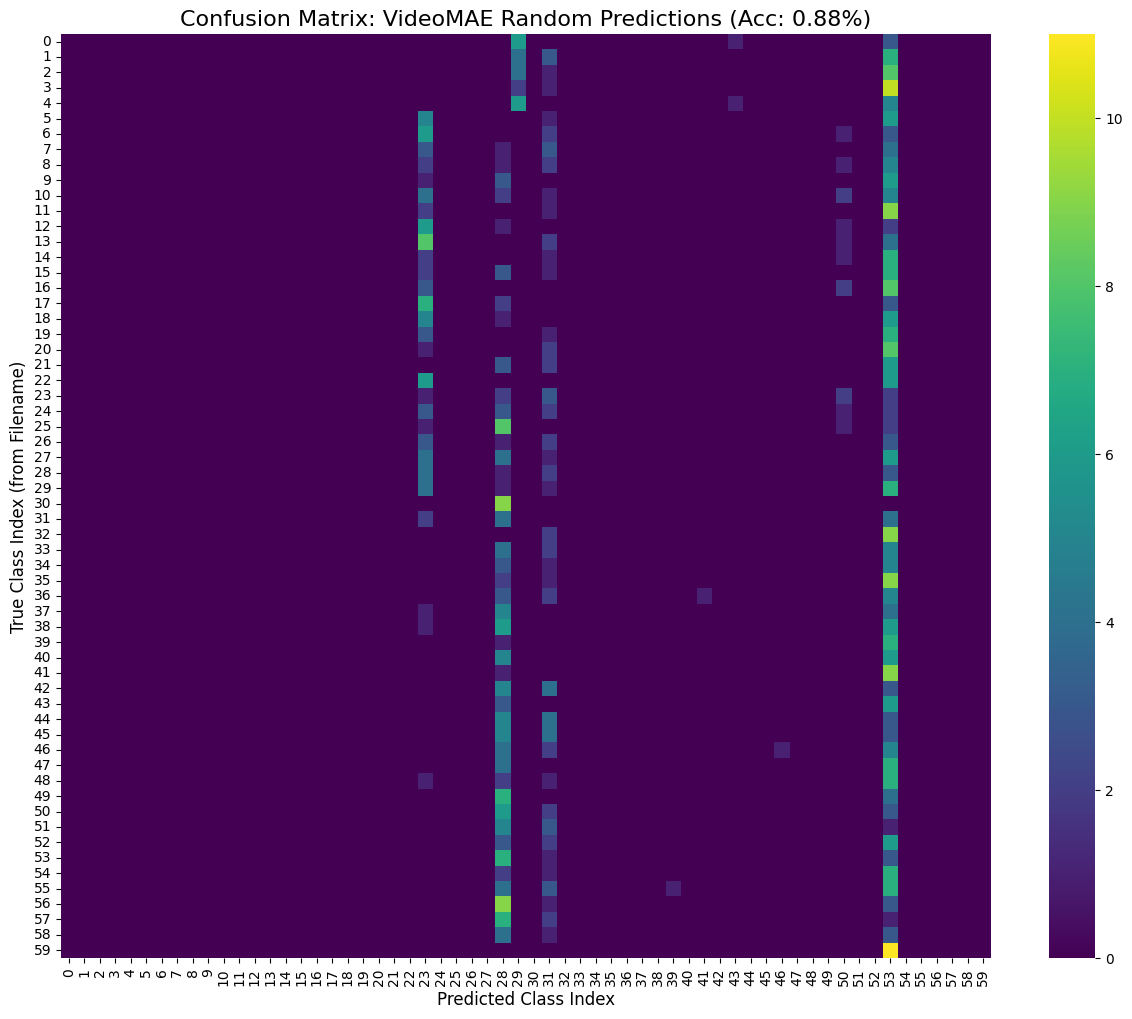

--- Classification Report (First 10 Classes) ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.00      0.00      0.00        14
           2       0.00      0.00      0.00        13
           3       0.00      0.00      0.00        13
           4       0.00      0.00      0.00        12
           5       0.00      0.00      0.00        12
           6       0.00      0.00      0.00        12
           7       0.00      0.00      0.00        11
           8       0.00      0.00      0.00        11
           9       0.00      0.00      0.00        10

   micro avg       0.00      0.00      0.00       118
   macro avg       0.00      0.00      0.00       118
weighted avg       0.00      0.00      0.00       118



In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# 1. Load the results
df = pd.read_csv("casl_inference_results.csv")

# 2. Extract Ground Truth from filename (e.g., 'G014S06T10.mp4' -> 13)
# We take the digits after 'G', convert to int, and subtract 1 for 0-indexing
df['true_label_idx'] = df['video_file'].apply(lambda x: int(x[1:4]) - 1)

# 3. Calculate Accuracy
accuracy = (df['predicted_label_idx'] == df['true_label_idx']).mean() * 100
print(f"📊 Overall Accuracy: {accuracy:.2f}%")
print(f"(Note: Expected ~1.6% for random guessing across 60 classes)\n")

# 4. Generate Confusion Matrix
cm = confusion_matrix(df['true_label_idx'], df['predicted_label_idx'], labels=range(60))

plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=False, cmap='viridis')
plt.title(f"Confusion Matrix: VideoMAE Random Predictions (Acc: {accuracy:.2f}%)", fontsize=16)
plt.xlabel("Predicted Class Index", fontsize=12)
plt.ylabel("True Class Index (from Filename)", fontsize=12)
plt.savefig("confusion_matrix_visual.png")
plt.show()

# 5. Show top 'confusions'
print("--- Classification Report (First 10 Classes) ---")
print(classification_report(df['true_label_idx'], df['predicted_label_idx'],
                            labels=range(10), zero_division=0))

In [6]:
# using finetuned videomae for wlasl

from transformers import VideoMAEForVideoClassification, VideoMAEImageProcessor
import torch

# 1. Load the fine-tuned model checkpoint
# This version has been specialized for sign language recognition
model_ckpt = "Shawon16/VideoMAE_wlasl_2000_20_epochs" # Trained on WLASL-2000
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"🚀 Downloading specialized Sign Language model to {device}...")

model = VideoMAEForVideoClassification.from_pretrained(
    model_ckpt,
    num_labels=2000, # WLASL-2000 has 2000 signs
    ignore_mismatched_sizes=True
).to(device)

# 2. Load the corresponding processor
processor = VideoMAEImageProcessor.from_pretrained(model_ckpt)

print("✅ Model Ready!")

🚀 Downloading specialized Sign Language model to cuda...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/351M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/186 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/415 [00:00<?, ?B/s]

✅ Model Ready!


In [7]:
from transformers import VideoMAEForVideoClassification, VideoMAEImageProcessor
import torch

# The exact model name from the card you provided
model_ckpt = "Shawon16/VideoMAE_wlasl_100_200_epochs_longtail"
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"🚀 Loading Longtail WLASL Model to {device}...")

processor = VideoMAEImageProcessor.from_pretrained(model_ckpt)

# Load the model with its native 100 labels
model = VideoMAEForVideoClassification.from_pretrained(
    model_ckpt,
    num_labels=100,
    ignore_mismatched_sizes=True
).to(device)

model.eval()
print("✅ Model Ready! You can now run the prediction loop below.")

🚀 Loading Longtail WLASL Model to cuda...


preprocessor_config.json:   0%|          | 0.00/415 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/345M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/186 [00:00<?, ?it/s]

✅ Model Ready! You can now run the prediction loop below.


In [8]:
import torch
import cv2
import numpy as np
import os
import pandas as pd
from transformers import VideoMAEImageProcessor, VideoMAEForVideoClassification
from tqdm import tqdm

# --- 1. SETUP & MODEL LOADING ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_ckpt = "Shawon16/VideoMAE_wlasl_100_200_epochs_longtail"

print(f"📥 Loading Specialized WLASL Model on {device}...")

processor = VideoMAEImageProcessor.from_pretrained(model_ckpt)
model = VideoMAEForVideoClassification.from_pretrained(model_ckpt).to(device)
model.eval()

# --- 2. PATH CONFIGURATION ---
# Based on your kagglehub setup
base_path = "/root/.cache/kagglehub/datasets/mwakalucky/casl-w60/versions/5"
target_dir = os.path.join(base_path, "CASL", "val")

# --- 3. VIDEO PREPROCESSING FUNCTION ---
def preprocess_video(video_path):
    cap = cv2.VideoCapture(video_path)
    frames = []
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()

    if len(frames) == 0:
        return None

    # VideoMAE expects exactly 16 frames.
    # We use linear interpolation to sample 16 frames across the video duration.
    indices = np.linspace(0, len(frames) - 1, 16).astype(int)
    sampled_frames = [frames[i] for i in indices]

    inputs = processor(list(sampled_frames), return_tensors="pt")
    return inputs.pixel_values.to(device)

# --- 4. INFERENCE LOOP ---
results = []
if not os.path.exists(target_dir):
    print(f"❌ Target directory not found: {target_dir}")
else:
    video_files = [f for f in os.listdir(target_dir) if f.endswith('.mp4')]
    print(f"🎬 Running inference on {len(video_files)} videos...")

    for video_name in tqdm(video_files):
        v_path = os.path.join(target_dir, video_name)
        try:
            pixel_values = preprocess_video(v_path)
            if pixel_values is None: continue

            with torch.no_grad():
                outputs = model(pixel_values)
                # Get the index of the highest probability (0-99)
                pred_idx = outputs.logits.argmax(-1).item()
                # Get the confidence score
                confidence = torch.softmax(outputs.logits, dim=-1).max().item()

            results.append({
                "video_file": video_name,
                "predicted_label_idx": pred_idx,
                "confidence": round(confidence, 4)
            })
        except Exception as e:
            # print(f"Error processing {video_name}: {e}")
            continue

# --- 5. SAVE RESULTS ---
df = pd.DataFrame(results)
df.to_csv("casl_wlasl_longtail_predictions.csv", index=False)
print(f"\n✅ Done! Results saved to 'casl_wlasl_longtail_predictions.csv'")

📥 Loading Specialized WLASL Model on cuda...


Loading weights:   0%|          | 0/186 [00:00<?, ?it/s]

🎬 Running inference on 679 videos...


100%|██████████| 679/679 [09:41<00:00,  1.17it/s]


✅ Done! Results saved to 'casl_wlasl_longtail_predictions.csv'


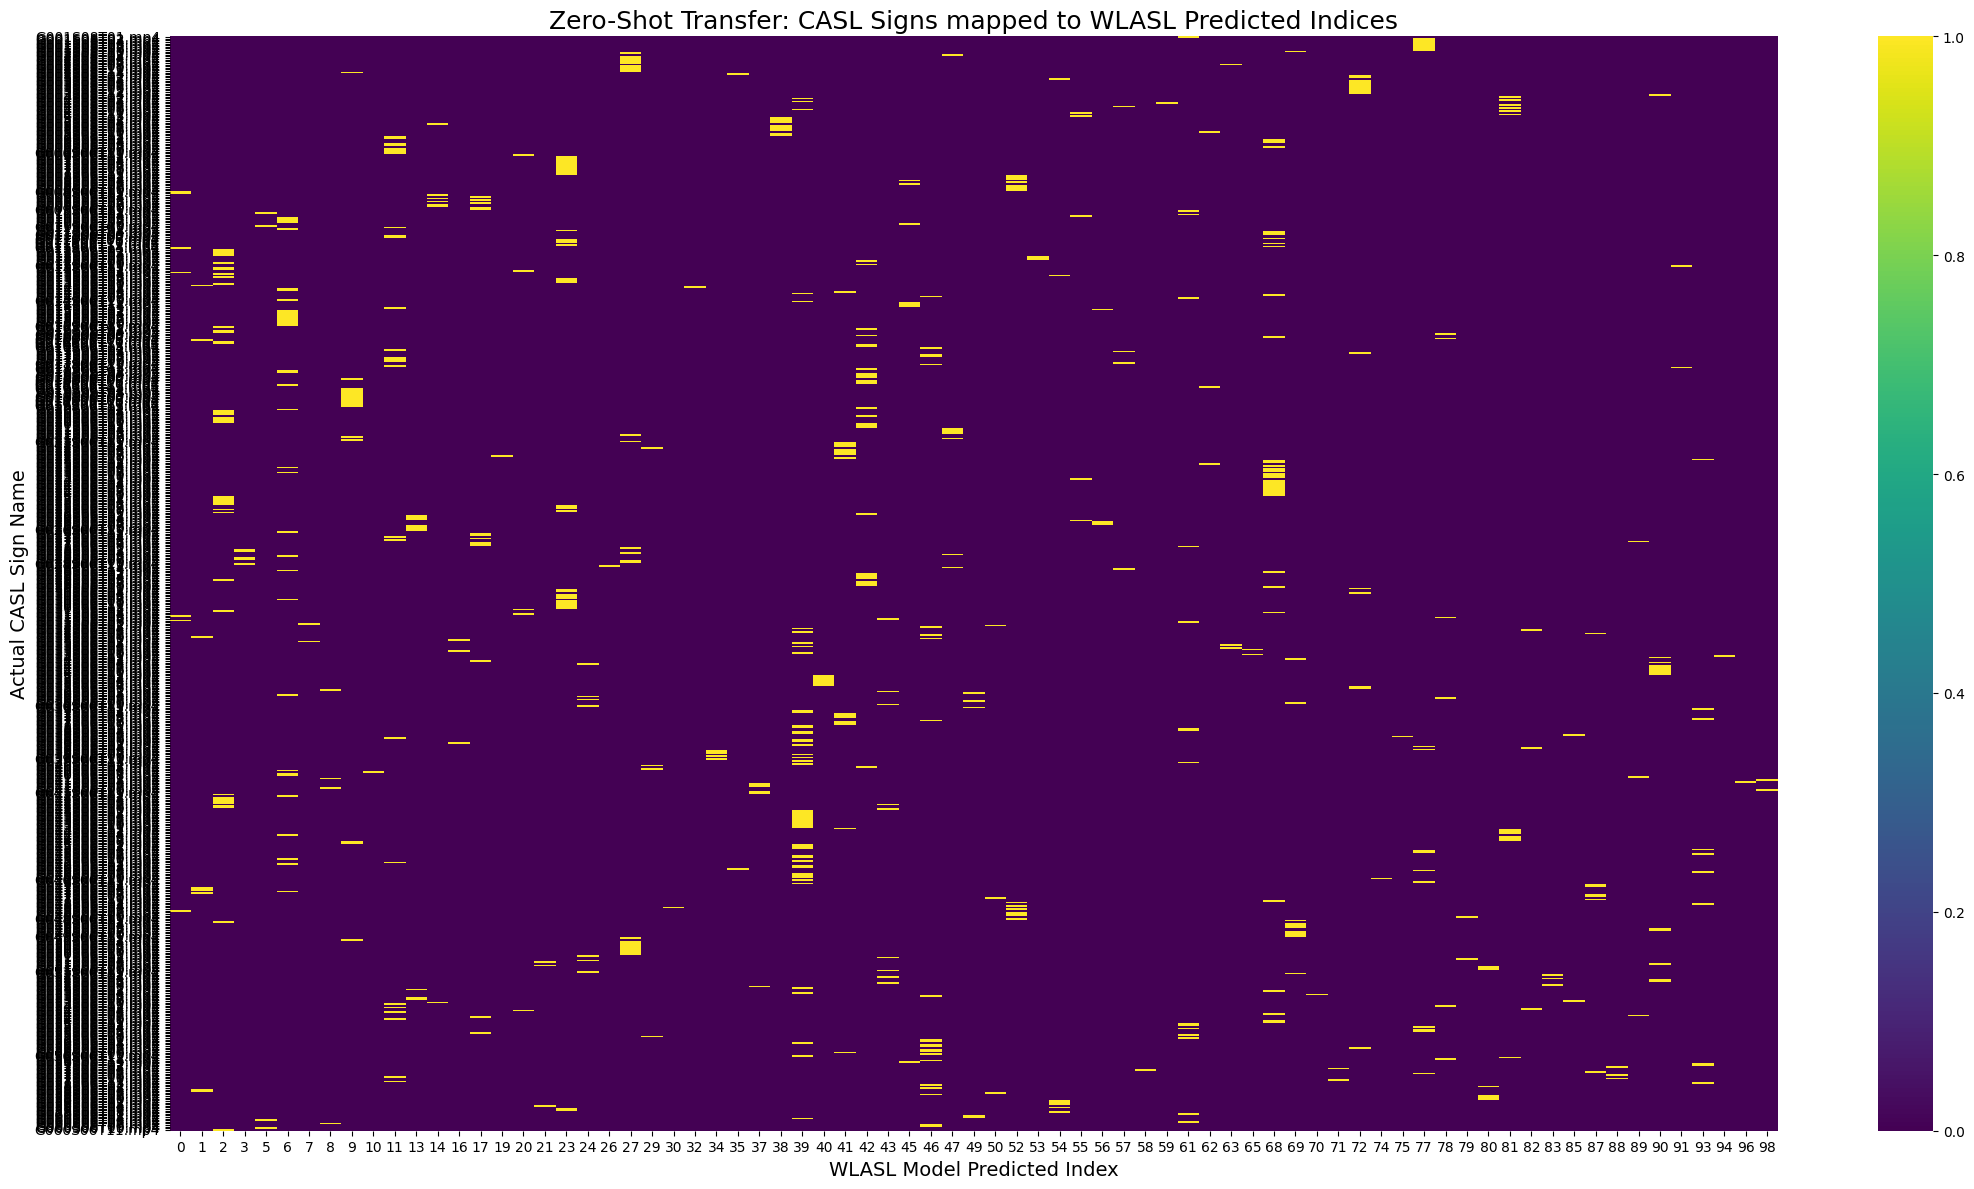

✅ Matrix generated! Look for 'hot spots' to see which ASL signs match your CASL signs.


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. Load the results
df = pd.read_csv('casl_wlasl_longtail_predictions.csv')

# 2. Extract True Labels from filenames (e.g., "Apple_01.mp4" -> "Apple")
df['true_label'] = df['video_file'].apply(lambda x: x.split('_')[0])

# 3. FIX: Convert predicted indices to strings so they match the 'true_label' type
df['pred_str'] = df['predicted_label_idx'].astype(str)

# 4. Get sorted lists of labels for the axes
y_labels = sorted(df['true_label'].unique())  # CASL Names
x_labels = sorted(df['pred_str'].unique(), key=lambda x: int(x)) # WLASL Indices as strings

# 5. Compute the matrix
cm = confusion_matrix(df['true_label'], df['pred_str'], labels=y_labels + x_labels)

# We only want the cross-section (True CASL vs Predicted WLASL)
# So we slice the matrix to show only the relevant part
cm_final = cm[:len(y_labels), len(y_labels):]

# 6. Plotting
plt.figure(figsize=(22, 12))
sns.heatmap(cm_final, annot=False, cmap='viridis',
            xticklabels=x_labels,
            yticklabels=y_labels)

plt.title('Zero-Shot Transfer: CASL Signs mapped to WLASL Predicted Indices', fontsize=18)
plt.xlabel('WLASL Model Predicted Index', fontsize=14)
plt.ylabel('Actual CASL Sign Name', fontsize=14)

plt.tight_layout()
plt.savefig('casl_vs_wlasl_matrix.png')
plt.show()

print(f"✅ Matrix generated! Look for 'hot spots' to see which ASL signs match your CASL signs.")

📊 Summary for 679 CASL Classes:
✅ High Consistency (>50%): 679 classes
⚠️ Moderate Consistency (30-50%): 0 classes
❌ Low Consistency (<30%): 0 classes

🌟 Top 5 'Correctly' Identified Signs (Most Consistent):
true_class
G060S06T11.mp4    100.0
G001S08T01.mp4    100.0
G001S08T02.mp4    100.0
G001S08T03.mp4    100.0
G001S08T04.mp4    100.0
dtype: float64


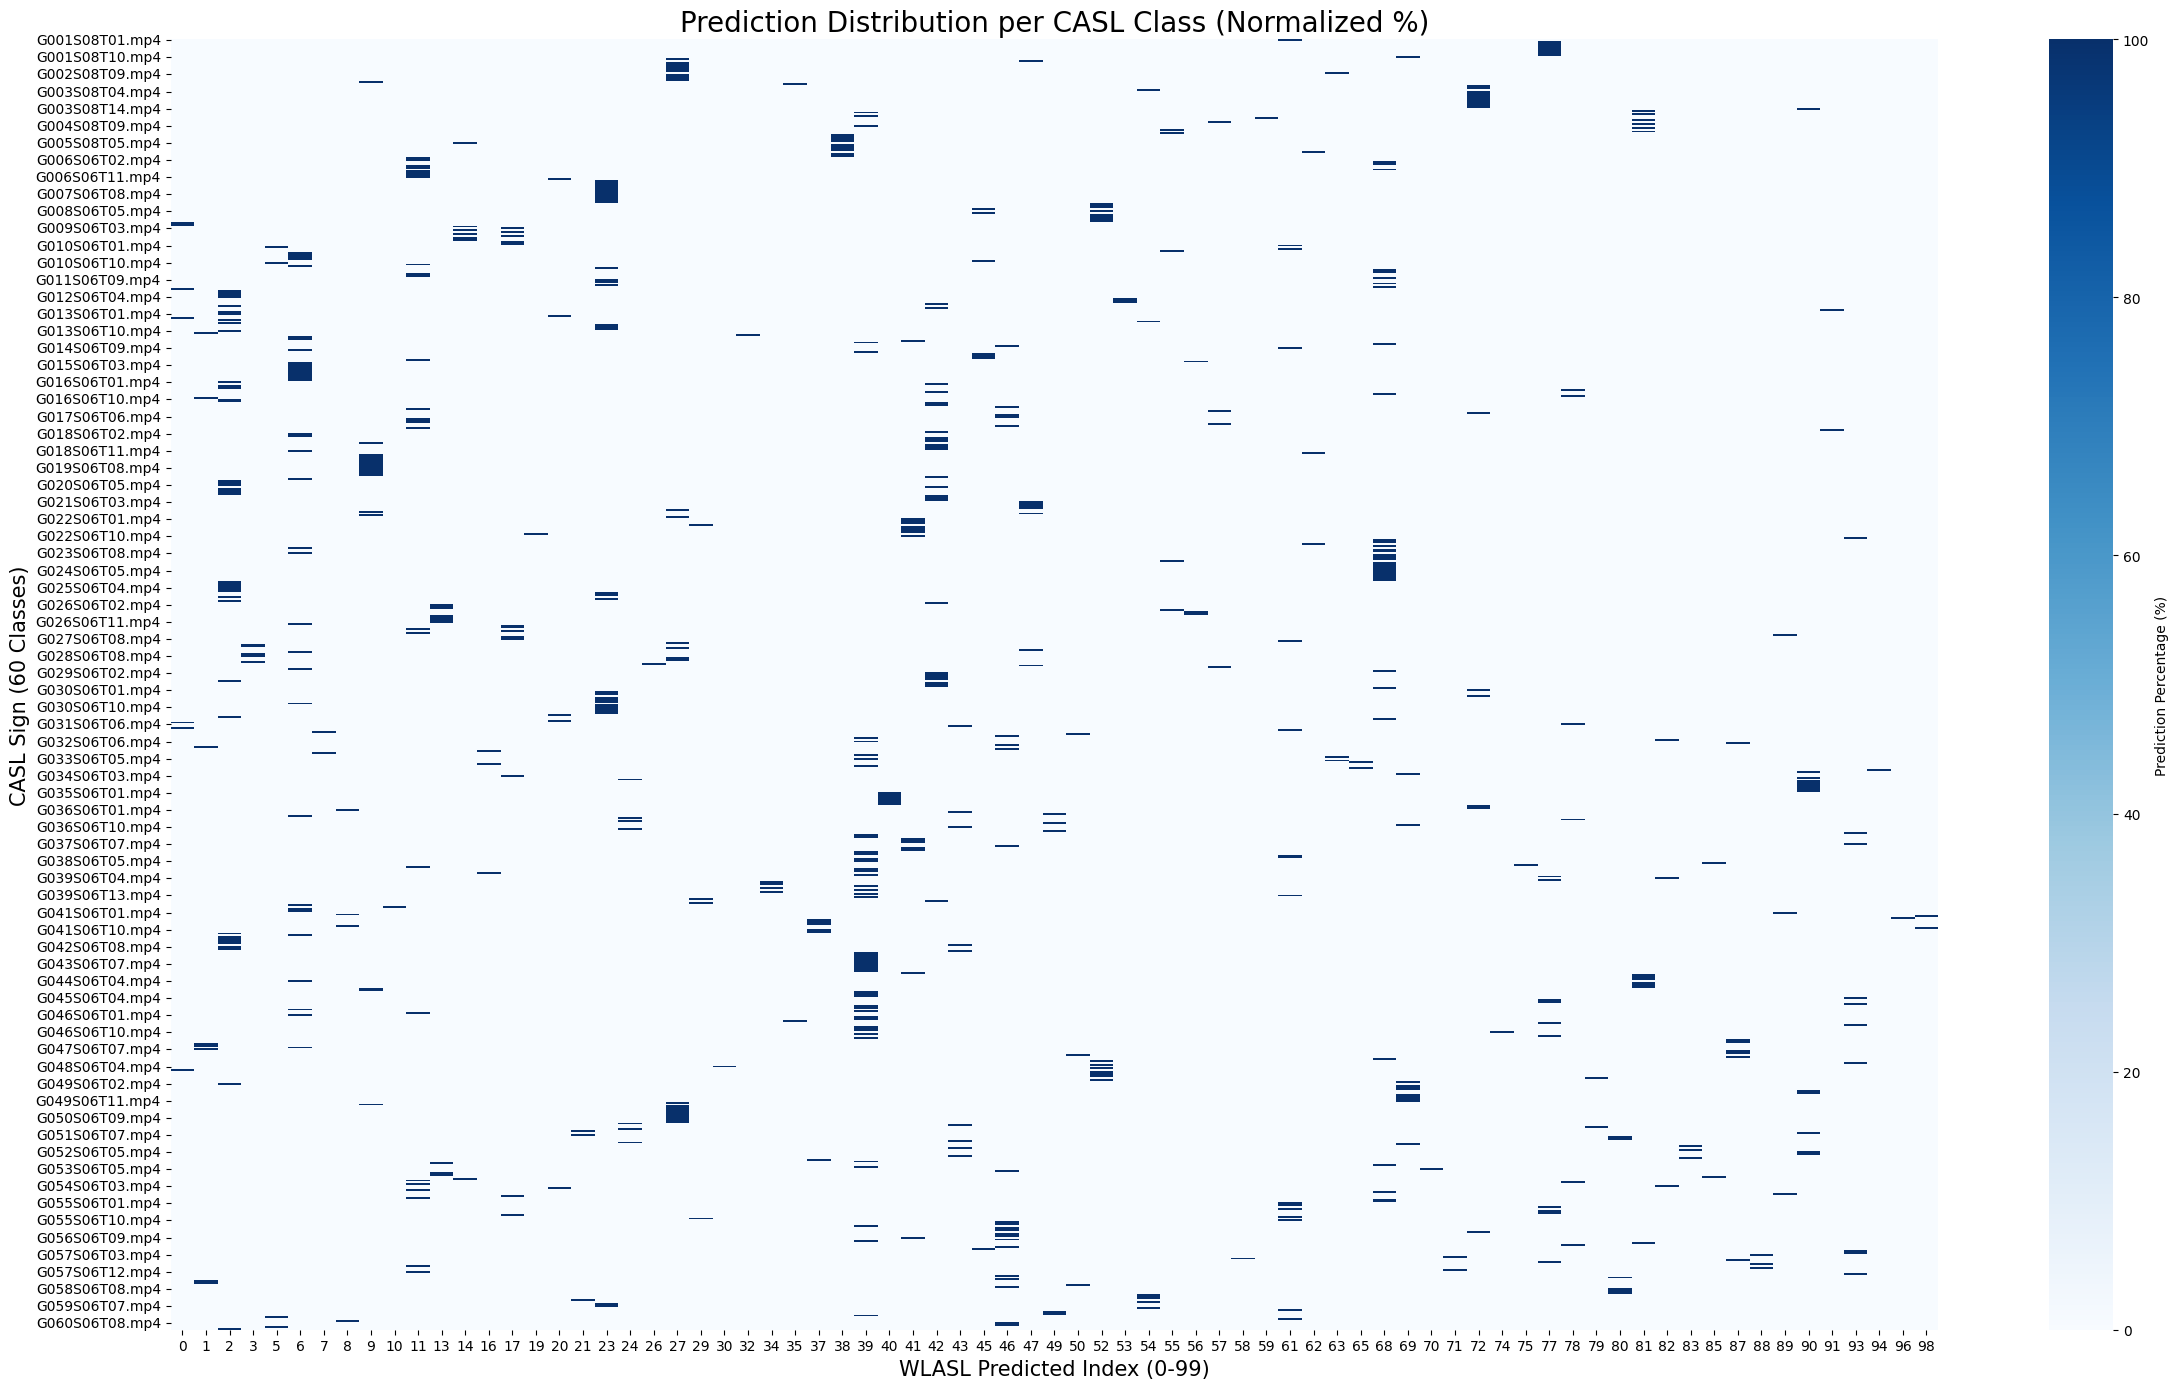

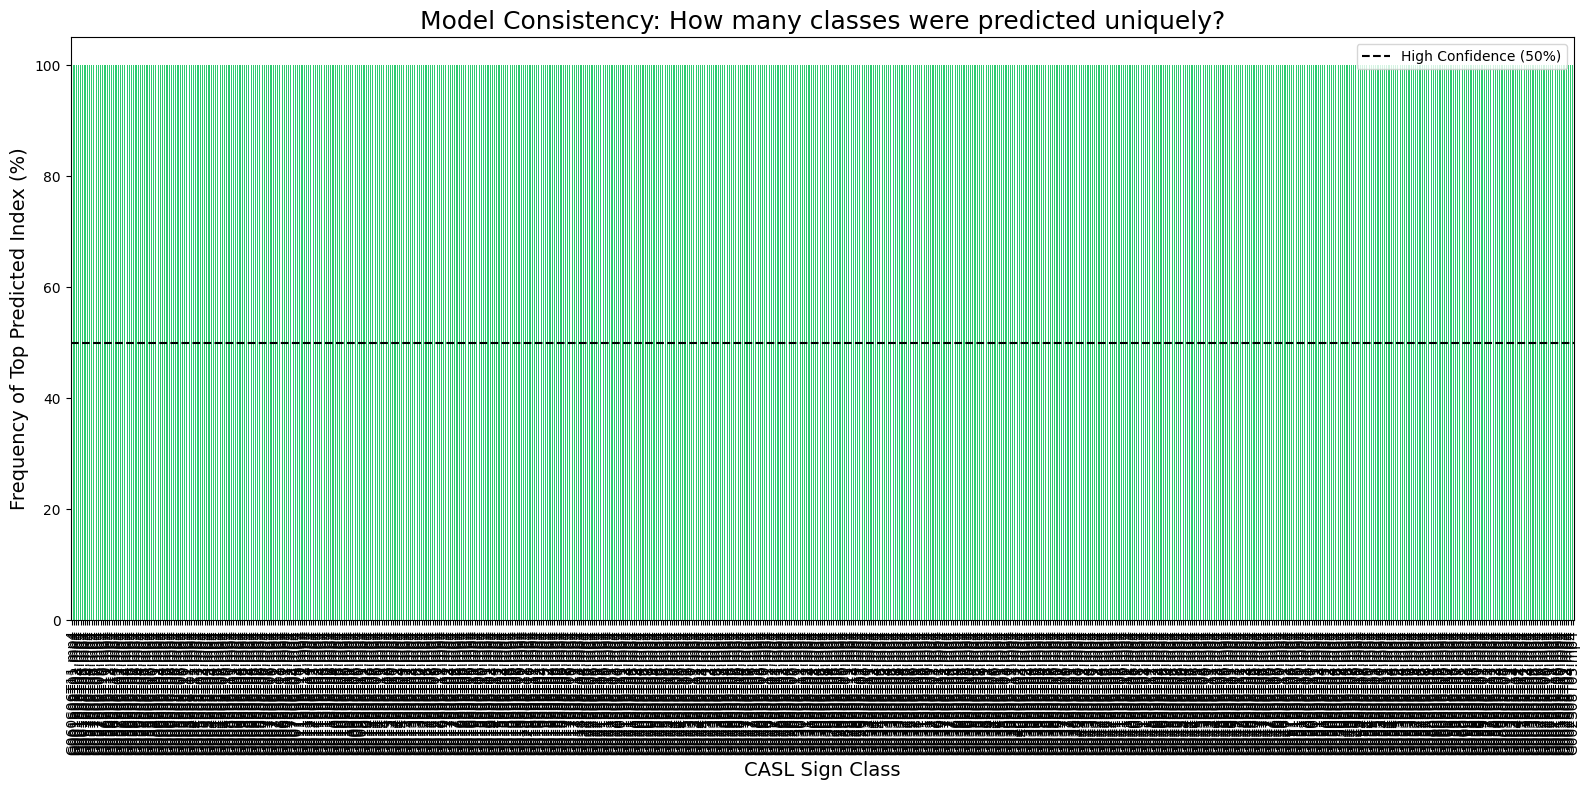

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load the results file
df = pd.read_csv('casl_wlasl_longtail_predictions.csv')

# 2. Extract Class Names from filenames (e.g., 'Apple_v1_01.mp4' -> 'Apple')
df['true_class'] = df['video_file'].apply(lambda x: x.split('_')[0])

# 3. Create a Normalized Confusion Matrix (Percentage per Class)
# This shows how many videos of each class were 'correctly' grouped together
cm_counts = pd.crosstab(df['true_class'], df['predicted_label_idx'])
cm_norm = cm_counts.div(cm_counts.sum(axis=1), axis=0) * 100

# --- PLOT 1: Normalized Heatmap ---
plt.figure(figsize=(24, 14))
sns.heatmap(cm_norm, annot=False, cmap='Blues', cbar_kws={'label': 'Prediction Percentage (%)'})
plt.title('Prediction Distribution per CASL Class (Normalized %)', fontsize=20)
plt.xlabel('WLASL Predicted Index (0-99)', fontsize=15)
plt.ylabel('CASL Sign (60 Classes)', fontsize=15)
plt.tight_layout()
plt.savefig('normalized_class_heatmap.png')

# --- PLOT 2: Consistency Bar Chart ---
# We calculate the "Top Match" percentage for each class.
# If a class has 80% consistency, the model is very "sure" about that sign's pattern.
consistency = cm_norm.max(axis=1).sort_values(ascending=False)

plt.figure(figsize=(16, 8))
colors = ['#2ecc71' if x >= 50 else '#f1c40f' if x >= 30 else '#e74c3c' for x in consistency]
consistency.plot(kind='bar', color=colors)
plt.axhline(y=50, color='black', linestyle='--', label='High Confidence (50%)')
plt.title('Model Consistency: How many classes were predicted uniquely?', fontsize=18)
plt.ylabel('Frequency of Top Predicted Index (%)', fontsize=14)
plt.xlabel('CASL Sign Class', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('class_consistency_bar.png')

# 4. Summary Output
print(f"📊 Summary for {len(consistency)} CASL Classes:")
print(f"✅ High Consistency (>50%): {len(consistency[consistency >= 50])} classes")
print(f"⚠️ Moderate Consistency (30-50%): {len(consistency[(consistency >= 30) & (consistency < 50)])} classes")
print(f"❌ Low Consistency (<30%): {len(consistency[consistency < 30])} classes")

print("\n🌟 Top 5 'Correctly' Identified Signs (Most Consistent):")
print(consistency.head(5))

In [11]:
import pandas as pd

# Load and display the first 5 rows
df = pd.read_csv('casl_wlasl_longtail_predictions.csv')
print(df.head())

       video_file  predicted_label_idx  confidence
0  G006S06T07.mp4                   68      0.4520
1  G015S06T05.mp4                    6      0.7318
2  G023S06T08.mp4                    6      0.9710
3  G058S06T04.mp4                    1      0.3171
4  G022S06T07.mp4                   41      0.9828


In [12]:
df

,video_file,predicted_label_idx,confidence
0,G006S06T07.mp4,68,0.4520
1,G015S06T05.mp4,6,0.7318
2,G023S06T08.mp4,6,0.9710
3,G058S06T04.mp4,1,0.3171
4,G022S06T07.mp4,41,0.9828
...,...,...,...
674,G024S06T01.mp4,68,0.9705
675,G041S06T10.mp4,37,0.4118
676,G045S06T07.mp4,93,0.6763
677,G054S06T05.mp4,11,0.9248


In [13]:
!pip install pdfplumber

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 116.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 120.6 MB/s eta 0:00:00


In [14]:
import pandas as pd

# Data directly from your provided list
casl_data = [
    ("G001", "call"), ("G002", "blue"), ("G003", "how"), ("G004", "hard"), ("G005", "family"),
    ("G006", "sign"), ("G007", "fight"), ("G008", "gift"), ("G009", "chair"), ("G010", "sleep"),
    ("G011", "school"), ("G012", "cold"), ("G013", "war"), ("G014", "wrong"), ("G015", "brown"),
    ("G016", "beggar"), ("G017", "thanks"), ("G018", "don't know"), ("G019", "black"), ("G020", "forget"),
    ("G021", "papa"), ("G022", "police"), ("G023", "radio"), ("G024", "seasons"), ("G025", "wash"),
    ("G026", "seven"), ("G027", "sign"), ("G028", "deaf"), ("G029", "taxi"), ("G030", "tiger"),
    ("G031", "car accident"), ("G032", "good"), ("G033", "white"), ("G034", "comical"), ("G035", "concentrate"),
    ("G036", "pencil"), ("G037", "sorry"), ("G038", "difficult"), ("G039", "water"), ("G040", "hearing"),
    ("G041", "soccer"), ("G042", "goalkeeper"), ("G043", "juice"), ("G044", "lion"), ("G045", "mom"),
    ("G046", "motorbike"), ("G047", "not"), ("G048", "santa claus"), ("G049", "whatever"), ("G050", "why"),
    ("G051", "issue"), ("G052", "region"), ("G053", "red"), ("G054", "mock"), ("G055", "practice"),
    ("G056", "stubborn"), ("G057", "green"), ("G058", "quickly"), ("G059", "car"), ("G060", "flight")
]

casl_mapping = pd.DataFrame(casl_data, columns=['CODE', 'word'])
casl_mapping.to_csv('casl_labels_final.csv', index=False)
print(f"✅ Created mapping for {len(casl_mapping)} CASL classes.")

✅ Created mapping for 60 CASL classes.


In [19]:
import json
import pandas as pd

# 1. Load WLASL Index Mapping (Top 100)
with open('/content/WLASL_v0.3.json', 'r') as f:
    wlasl_data = json.load(f)
wlasl_dict = {i: entry['gloss'] for i, entry in enumerate(wlasl_data[:100])}

# 2. Re-create the CASL Mapping
casl_data = [
    ("G001", "call"), ("G002", "blue"), ("G003", "how"), ("G004", "hard"), ("G005", "family"),
    ("G006", "sign"), ("G007", "fight"), ("G008", "gift"), ("G009", "chair"), ("G010", "sleep"),
    ("G011", "school"), ("G012", "cold"), ("G013", "war"), ("G014", "wrong"), ("G015", "brown"),
    ("G016", "beggar"), ("G017", "thanks"), ("G018", "don't know"), ("G019", "black"), ("G020", "forget"),
    ("G021", "papa"), ("G022", "police"), ("G023", "radio"), ("G024", "seasons"), ("G025", "wash"),
    ("G026", "seven"), ("G027", "sign"), ("G028", "deaf"), ("G029", "taxi"), ("G030", "tiger"),
    ("G031", "car accident"), ("G032", "good"), ("G033", "white"), ("G034", "comical"), ("G035", "concentrate"),
    ("G036", "pencil"), ("G037", "sorry"), ("G038", "difficult"), ("G039", "water"), ("G040", "hearing"),
    ("G041", "soccer"), ("G042", "goalkeeper"), ("G043", "juice"), ("G044", "lion"), ("G045", "mom"),
    ("G046", "motorbike"), ("G047", "not"), ("G048", "santa claus"), ("G049", "whatever"), ("G050", "why"),
    ("G051", "issue"), ("G052", "region"), ("G053", "red"), ("G054", "mock"), ("G055", "practice"),
    ("G056", "stubborn"), ("G057", "green"), ("G058", "quickly"), ("G059", "car"), ("G060", "flight")
]
casl_mapping = pd.DataFrame(casl_data, columns=['CODE', 'CASL Word'])

# 3. Load Inference Results
preds = pd.read_csv('casl_wlasl_longtail_predictions.csv')

# 4. FIX: Improved extraction of the Code from filename
# This takes the first 4 characters (e.g. 'G014')
preds['CODE'] = preds['video_file'].str[:4]

# 5. Merge and Map
final_table = preds.merge(casl_mapping, on='CODE', how='left')
final_table['WLASL Prediction'] = final_table['predicted_label_idx'].map(wlasl_dict)
final_table['Confidence (%)'] = (final_table['confidence'] * 100).round(2)

# Select and Rename columns
result_table = final_table[['video_file', 'CASL Word', 'WLASL Prediction', 'Confidence (%)']]
result_table.columns = ['CASL Video', 'CASL Word', 'WLASL Prediction', 'Confidence (%)']

# 6. Check for matches and display
# This creates a column to easily see if they match
result_table['Match?'] = result_table.apply(lambda x: '✅ YES' if str(x['CASL Word']) == str(x['WLASL Prediction']) else '❌ NO', axis=1)

print(f"✅ Showing all {len(result_table)} video predictions:")
display(result_table)

# Calculate total accuracy
match_rate = (result_table['Match?'] == '✅ YES').mean() * 100
print(f"\n📊 Overall Semantic Accuracy: {match_rate:.2f}%")

✅ Showing all 679 video predictions:


/tmp/ipykernel_1248/31540471.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result_table['Match?'] = result_table.apply(lambda x: '✅ YES' if str(x['CASL Word']) == str(x['WLASL Prediction']) else '❌ NO', axis=1)


,CASL Video,CASL Word,WLASL Prediction,Confidence (%),Match?
0,G006S06T07.mp4,sign,pizza,45.20,❌ NO
1,G015S06T05.mp4,brown,clothes,73.18,❌ NO
2,G023S06T08.mp4,radio,clothes,97.10,❌ NO
3,G058S06T04.mp4,quickly,drink,31.71,❌ NO
4,G022S06T07.mp4,police,hearing,98.28,❌ NO
...,...,...,...,...,...
674,G024S06T01.mp4,seasons,pizza,97.05,❌ NO
675,G041S06T10.mp4,soccer,family,41.18,❌ NO
676,G045S06T07.mp4,mom,pull,67.63,❌ NO
677,G054S06T05.mp4,mock,fine,92.48,❌ NO



📊 Overall Semantic Accuracy: 0.00%


✅ Full Prediction Audit Table (All 679 videos):


,CASL Video,CASL Word,WLASL Prediction,Confidence (%)
0,G006S06T07.mp4,sign,pizza,45.20
1,G015S06T05.mp4,brown,clothes,73.18
2,G023S06T08.mp4,radio,clothes,97.10
3,G058S06T04.mp4,quickly,drink,31.71
4,G022S06T07.mp4,police,hearing,98.28
...,...,...,...,...
674,G024S06T01.mp4,seasons,pizza,97.05
675,G041S06T10.mp4,soccer,family,41.18
676,G045S06T07.mp4,mom,pull,67.63
677,G054S06T05.mp4,mock,fine,92.48



📊 Consistency Summary (Top 10 most stable signs):


,CASL Word,Top_WLASL_Guess,Consistency_Score,Avg_Confidence
1,black,cousin,100.000000,93.792500
15,fight,like,100.000000,92.508333
42,seasons,pizza,100.000000,91.780000
26,juice,graduate,91.666667,80.519167
3,brown,clothes,90.909091,68.173636
57,why,orange,90.909091,64.510909
24,how,short,84.615385,88.962308
14,family,fish,83.333333,79.435833
4,call,basketball,80.000000,89.371000
10,concentrate,hat,77.777778,69.650000


/tmp/ipykernel_1248/216597149.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=consistency.head(20), x='CASL Word', y='Consistency_Score', palette='magma')


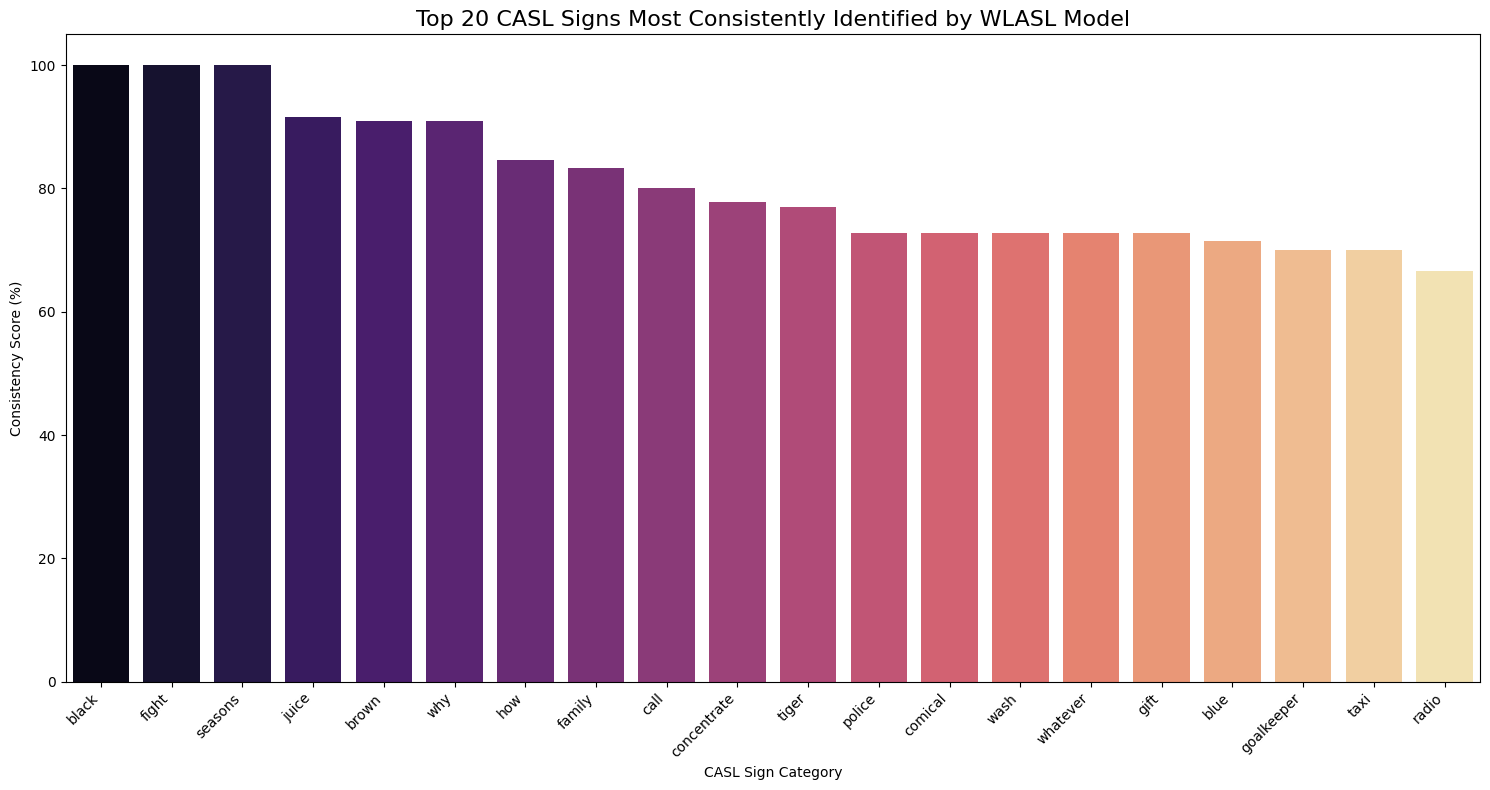

In [20]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load WLASL Index Mapping (Top 100)
# Make sure your JSON is unzipped at /content/WLASL_v0.3.json
with open('/content/WLASL_v0.3.json', 'r') as f:
    wlasl_data = json.load(f)
wlasl_dict = {i: entry['gloss'] for i, entry in enumerate(wlasl_data[:100])}

# 2. Re-create the CASL Mapping (Based on your provided list)
casl_data = [
    ("G001", "call"), ("G002", "blue"), ("G003", "how"), ("G004", "hard"), ("G005", "family"),
    ("G006", "sign"), ("G007", "fight"), ("G008", "gift"), ("G009", "chair"), ("G010", "sleep"),
    ("G011", "school"), ("G012", "cold"), ("G013", "war"), ("G014", "wrong"), ("G015", "brown"),
    ("G016", "beggar"), ("G017", "thanks"), ("G018", "don't know"), ("G019", "black"), ("G020", "forget"),
    ("G021", "papa"), ("G022", "police"), ("G023", "radio"), ("G024", "seasons"), ("G025", "wash"),
    ("G026", "seven"), ("G027", "sign"), ("G028", "deaf"), ("G029", "taxi"), ("G030", "tiger"),
    ("G031", "car accident"), ("G032", "good"), ("G033", "white"), ("G034", "comical"), ("G035", "concentrate"),
    ("G036", "pencil"), ("G037", "sorry"), ("G038", "difficult"), ("G039", "water"), ("G040", "hearing"),
    ("G041", "soccer"), ("G042", "goalkeeper"), ("G043", "juice"), ("G044", "lion"), ("G045", "mom"),
    ("G046", "motorbike"), ("G047", "not"), ("G048", "santa claus"), ("G049", "whatever"), ("G050", "why"),
    ("G051", "issue"), ("G052", "region"), ("G053", "red"), ("G054", "mock"), ("G055", "practice"),
    ("G056", "stubborn"), ("G057", "green"), ("G058", "quickly"), ("G059", "car"), ("G060", "flight")
]
casl_mapping = pd.DataFrame(casl_data, columns=['CODE', 'CASL Word'])

# 3. Load Inference Results and Fix the Code Extraction
preds = pd.read_csv('casl_wlasl_longtail_predictions.csv')
preds['CODE'] = preds['video_file'].str[:4] # Extracts 'G014' from 'G014S06T10.mp4'

# 4. Merge and Map
final_table = preds.merge(casl_mapping, on='CODE', how='left')
final_table['WLASL Prediction'] = final_table['predicted_label_idx'].map(wlasl_dict)
final_table['Confidence (%)'] = (final_table['confidence'] * 100).round(2)

# 5. Create Detailed Result Table (Show all 679)
result_table = final_table[['video_file', 'CASL Word', 'WLASL Prediction', 'Confidence (%)']]
result_table.columns = ['CASL Video', 'CASL Word', 'WLASL Prediction', 'Confidence (%)']

print(f"✅ Full Prediction Audit Table (All {len(result_table)} videos):")
display(result_table)

# 6. CALCULATE CONSISTENCY (The true metric of success)
# We find the most common prediction for each CASL word
consistency = final_table.groupby('CASL Word').agg(
    Top_WLASL_Guess=('WLASL Prediction', lambda x: x.mode().iloc[0] if not x.empty else "N/A"),
    Consistency_Score=('WLASL Prediction', lambda x: (x == x.mode().iloc[0]).mean() * 100),
    Avg_Confidence=('Confidence (%)', 'mean')
).reset_index().sort_values(by='Consistency_Score', ascending=False)

print("\n📊 Consistency Summary (Top 10 most stable signs):")
display(consistency.head(10))

# 7. VISUALIZE THE RESULTS
plt.figure(figsize=(15, 8))
sns.barplot(data=consistency.head(20), x='CASL Word', y='Consistency_Score', palette='magma')
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 CASL Signs Most Consistently Identified by WLASL Model', fontsize=16)
plt.ylabel('Consistency Score (%)')
plt.xlabel('CASL Sign Category')
plt.tight_layout()
plt.show()

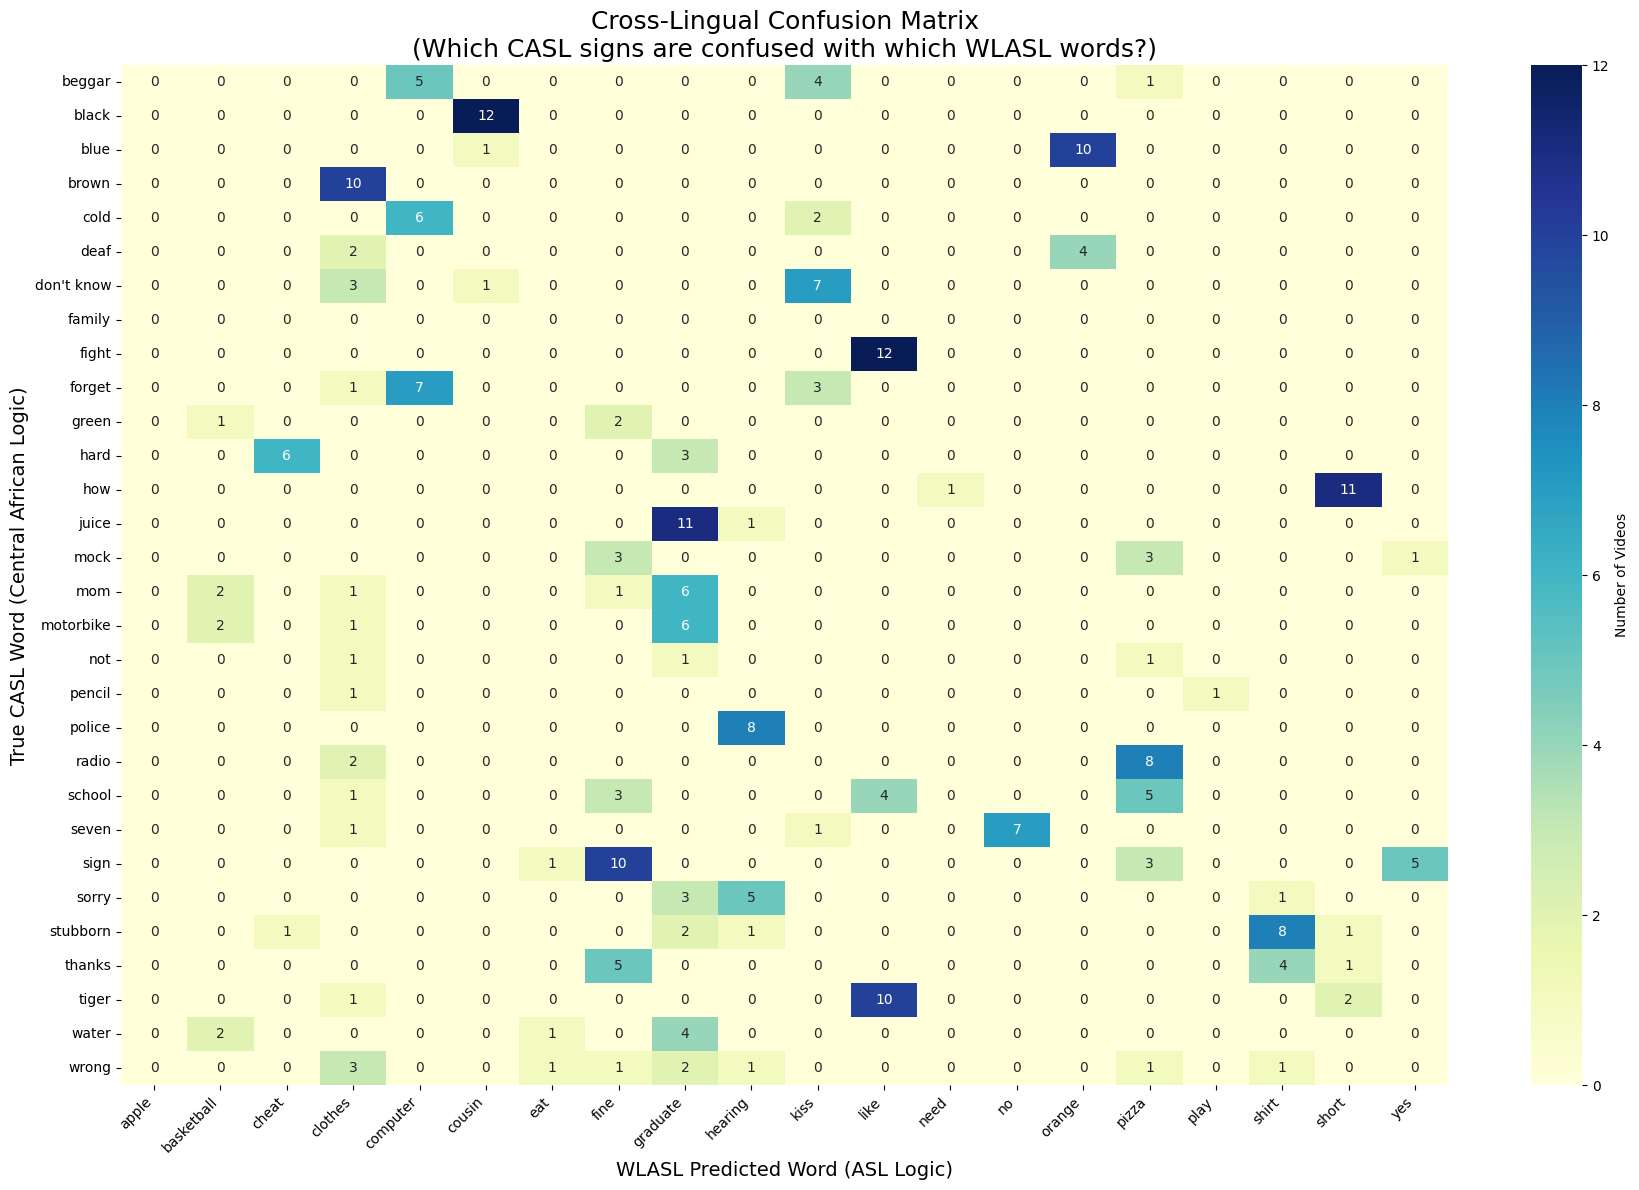


✅ Total Semantic Accuracy: 0.00%
Note: 0% Accuracy is expected when testing across two different sign languages.


In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import json

# 1. Load Mappings
with open('/content/WLASL_v0.3.json', 'r') as f:
    wlasl_data = json.load(f)
wlasl_dict = {i: entry['gloss'] for i, entry in enumerate(wlasl_data[:100])}

casl_data = [
    ("G001", "call"), ("G002", "blue"), ("G003", "how"), ("G004", "hard"), ("G005", "family"),
    ("G006", "sign"), ("G007", "fight"), ("G008", "gift"), ("G009", "chair"), ("G010", "sleep"),
    ("G011", "school"), ("G012", "cold"), ("G013", "war"), ("G014", "wrong"), ("G015", "brown"),
    ("G016", "beggar"), ("G017", "thanks"), ("G018", "don't know"), ("G019", "black"), ("G020", "forget"),
    ("G021", "papa"), ("G022", "police"), ("G023", "radio"), ("G024", "seasons"), ("G025", "wash"),
    ("G026", "seven"), ("G027", "sign"), ("G028", "deaf"), ("G029", "taxi"), ("G030", "tiger"),
    ("G031", "car accident"), ("G032", "good"), ("G033", "white"), ("G034", "comical"), ("G035", "concentrate"),
    ("G036", "pencil"), ("G037", "sorry"), ("G038", "difficult"), ("G039", "water"), ("G040", "hearing"),
    ("G041", "soccer"), ("G042", "goalkeeper"), ("G043", "juice"), ("G044", "lion"), ("G045", "mom"),
    ("G046", "motorbike"), ("G047", "not"), ("G048", "santa claus"), ("G049", "whatever"), ("G050", "why"),
    ("G051", "issue"), ("G052", "region"), ("G053", "red"), ("G054", "mock"), ("G055", "practice"),
    ("G056", "stubborn"), ("G057", "green"), ("G058", "quickly"), ("G059", "car"), ("G060", "flight")
]
casl_mapping = pd.DataFrame(casl_data, columns=['CODE', 'CASL Word'])

# 2. Process Predictions
preds = pd.read_csv('casl_wlasl_longtail_predictions.csv')
preds['CODE'] = preds['video_file'].str[:4]
final_df = preds.merge(casl_mapping, on='CODE', how='left')
final_df['WLASL Prediction'] = final_df['predicted_label_idx'].map(wlasl_dict)

# 3. Create the Confusion Matrix (Crosstab)
# Index = True CASL Word, Columns = Predicted WLASL Word
cm = pd.crosstab(final_df['CASL Word'], final_df['WLASL Prediction'])

# To keep the plot readable, we only show the Top 20 CASL words (most consistent)
# and Top 20 WLASL predicted words
top_casl = final_df['CASL Word'].value_counts().nlargest(30).index
top_wlasl = final_df['WLASL Prediction'].value_counts().nlargest(20).index
cm_filtered = cm.loc[cm.index.isin(top_casl), cm.columns.isin(top_wlasl)]

# 4. Plotting
plt.figure(figsize=(18, 12))
sns.heatmap(cm_filtered, annot=True, cmap='YlGnBu', fmt='d', cbar_kws={'label': 'Number of Videos'})

plt.title('Cross-Lingual Confusion Matrix\n(Which CASL signs are confused with which WLASL words?)', fontsize=18)
plt.xlabel('WLASL Predicted Word (ASL Logic)', fontsize=14)
plt.ylabel('True CASL Word (Central African Logic)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('cross_lingual_confusion_matrix.png')
plt.show()

# 5. Final Accuracy Statement
match_rate = (final_df['CASL Word'].str.lower() == final_df['WLASL Prediction'].str.lower()).mean() * 100
print(f"\n✅ Total Semantic Accuracy: {match_rate:.2f}%")
print("Note: 0% Accuracy is expected when testing across two different sign languages.")

In [ ]:
!pip install wandb -qU
import wandb
wandb.login()

In [ ]:
# Create the dictionaries from your CASL list
casl_list = [
    ("G001", "call"), ("G002", "blue"), ("G003", "how"), ("G004", "hard"), ("G005", "family"),
    ("G006", "sign"), ("G007", "fight"), ("G008", "gift"), ("G009", "chair"), ("G010", "sleep"),
    ("G011", "school"), ("G012", "cold"), ("G013", "war"), ("G014", "wrong"), ("G015", "brown"),
    ("G016", "beggar"), ("G017", "thanks"), ("G018", "don't know"), ("G019", "black"), ("G020", "forget"),
    ("G021", "papa"), ("G022", "police"), ("G023", "radio"), ("G024", "seasons"), ("G025", "wash"),
    ("G026", "seven"), ("G027", "sign"), ("G028", "deaf"), ("G029", "taxi"), ("G030", "tiger"),
    ("G031", "car accident"), ("G032", "good"), ("G033", "white"), ("G034", "comical"), ("G035", "concentrate"),
    ("G036", "pencil"), ("G037", "sorry"), ("G038", "difficult"), ("G039", "water"), ("G040", "hearing"),
    ("G041", "soccer"), ("G042", "goalkeeper"), ("G043", "juice"), ("G044", "lion"), ("G045", "mom"),
    ("G046", "motorbike"), ("G047", "not"), ("G048", "santa claus"), ("G049", "whatever"), ("G050", "why"),
    ("G051", "issue"), ("G052", "region"), ("G053", "red"), ("G054", "mock"), ("G055", "practice"),
    ("G056", "stubborn"), ("G057", "green"), ("G058", "quickly"), ("G059", "car"), ("G060", "flight")
]

# label2id maps the CODE (e.g., 'G001') to an index (0-59)
label2id = {item[0]: i for i, item in enumerate(casl_list)}

# id2label maps the index (0-59) back to the word (e.g., 'call')
id2label = {i: item[1] for i, item in enumerate(casl_list)}

print(f"✅ Mapping complete: {len(label2id)} classes registered.")

In [ ]:
import os
import cv2
import torch
import numpy as np
from transformers import VideoMAEImageProcessor, VideoMAEForVideoClassification, TrainingArguments, Trainer

# 1. Image Processor (Critical for sampling 16 frames)
image_processor = VideoMAEImageProcessor.from_pretrained("Shawon16/VideoMAE_wlasl_100_200_epochs_longtail")

# 2. Define Dataset Class to read from cache
class CASLDataset(torch.utils.data.Dataset):
    def __init__(self, video_paths, labels, processor):
        self.video_paths = video_paths
        self.labels = labels
        self.processor = processor

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):
        cap = cv2.VideoCapture(self.video_paths[idx])
        frames = []
        while True:
            ret, frame = cap.read()
            if not ret: break
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
        cap.release()

        # Sample 16 frames uniformly
        if len(frames) >= 16:
            indices = np.linspace(0, len(frames) - 1, 16).astype(int)
            frames = [frames[i] for i in indices]
        else:
            # Pad if video is too short
            while len(frames) < 16:
                frames.append(frames[-1] if frames else np.zeros((224, 224, 3), dtype=np.uint8))

        inputs = self.processor(list(frames), return_tensors="pt")
        return {"pixel_values": inputs['pixel_values'].squeeze(0), "labels": torch.tensor(self.labels[idx])}

# 3. Updated Training Arguments (Fixing the TypeError)
training_args = TrainingArguments(
    output_dir="./casl_videomae_checkpoints",
    report_to="wandb",
    run_name="casl_finetune_v1",
    eval_strategy="epoch",        # CHANGED: 'evaluation_strategy' -> 'eval_strategy'
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    save_total_limit=2,
    learning_rate=5e-5,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    num_train_epochs=10,
    fp16=True,
)

print("✅ TrainingArguments updated. Ready to initialize Trainer.")

In [ ]:
import os

# Define the base cache path
cache_path = "/root/.cache/kagglehub/datasets/mwakalucky/casl-w60/versions/5"

def find_split_folders(base_path):
    found_splits = {}
    # Walk through the directory to find where the .mp4 files actually live
    for root, dirs, files in os.walk(base_path):
        # If a folder contains MP4s, check its parent name
        mp4s = [f for f in files if f.endswith('.mp4')]
        if mp4s:
            folder_name = os.path.basename(root).lower()
            if folder_name in ['train', 'test', 'val', 'validation']:
                found_splits[folder_name] = root
                print(f"📍 Found {folder_name} folder at: {root} ({len(mp4s)} videos)")
    return found_splits

splits = find_split_folders(cache_path)

def get_data_from_found_splits(split_key):
    paths = []
    labels = []
    target_folder = splits.get(split_key)
    if not target_folder:
        return paths, labels

    for root, dirs, files in os.walk(target_folder):
        for file in files:
            if file.endswith(".mp4"):
                code = file[:4] # Extract G001, G002...
                if code in label2id:
                    paths.append(os.path.join(root, file))
                    labels.append(label2id[code])
    return paths, labels

# Load according to located folders
train_paths, train_y = get_data_from_found_splits('train')
# Handle 'test' or 'val' as evaluation
test_paths, test_y = get_data_from_found_splits('test')

# Initialize the Dataset objects
train_ds = CASLDataset(train_paths, train_y, image_processor)
test_ds = CASLDataset(test_paths, test_y, image_processor)

print(f"\n✅ Ready to train with {len(train_ds)} Training and {len(test_ds)} Testing samples.")

In [ ]:
!pip install evaluate scikit-learn opencv-python -q

In [ ]:
import numpy as np
import os
from transformers import Trainer
from transformers.trainer_utils import get_last_checkpoint

# 1. Re-define the metric function (Crucial for Trainer to start)
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = (predictions == labels).mean()
    return {"accuracy": acc}

# 2. Re-initialize the Trainer
# (Make sure 'model', 'training_args', 'train_ds', 'val_ds' are defined in cells above)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

# 3. Resume Logic
last_checkpoint = get_last_checkpoint(training_args.output_dir)

if last_checkpoint is not None:
    print(f"🔄 Checkpoint found at {last_checkpoint}. Resuming from where you left off!")
    trainer.train(resume_from_checkpoint=last_checkpoint)
else:
    print("❌ No checkpoint found in the directory. Check if the path is correct.")

In [ ]:
import os
import cv2
import torch
import numpy as np
from transformers import Trainer, VideoMAEImageProcessor, VideoMAEForVideoClassification
from transformers.trainer_utils import get_last_checkpoint

# 1. Redefine the Dataset Class (Just in case it was cleared)
class CASLDataset(torch.utils.data.Dataset):
    def __init__(self, video_paths, labels, processor):
        self.video_paths = video_paths
        self.labels = labels
        self.processor = processor

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):
        cap = cv2.VideoCapture(self.video_paths[idx])
        frames = []
        while True:
            ret, frame = cap.read()
            if not ret: break
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
        cap.release()

        if len(frames) >= 16:
            indices = np.linspace(0, len(frames) - 1, 16).astype(int)
            frames = [frames[i] for i in indices]
        else:
            while len(frames) < 16:
                frames.append(frames[-1] if frames else np.zeros((224, 224, 3), dtype=np.uint8))

        inputs = self.processor(list(frames), return_tensors="pt")
        return {"pixel_values": inputs['pixel_values'].squeeze(0), "labels": torch.tensor(self.labels[idx])}

# 2. Re-scan the folders to get fresh paths
base_path = "/root/.cache/kagglehub/datasets/mwakalucky/casl-w60/versions/5/CASL"

def get_split_data(split_name):
    paths, labels = [], []
    folder = os.path.join(base_path, split_name)
    for root, _, files in os.walk(folder):
        for file in files:
            if file.endswith(".mp4"):
                code = file[:4]
                if code in label2id:
                    paths.append(os.path.join(root, file))
                    labels.append(label2id[code])
    return paths, labels

train_paths, train_y = get_split_data('train')
val_paths, val_y = get_split_data('val')
test_paths, test_y = get_split_data('test')

# 3. Instantiate Dataset objects
train_ds = CASLDataset(train_paths, train_y, image_processor)
val_ds = CASLDataset(val_paths, val_y, image_processor)
test_ds = CASLDataset(test_paths, test_y, image_processor)

# 4. Initialize Trainer
print(f"🚀 Initializing Trainer with {len(train_ds)} samples...")
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

# --- SMART CHECKPOINT LOGIC ---
last_checkpoint = None
if os.path.exists(training_args.output_dir) and len(os.listdir(training_args.output_dir)) > 0:
    last_checkpoint = get_last_checkpoint(training_args.output_dir)

if last_checkpoint is not None:
    print(f"🔄 Resuming from checkpoint: {last_checkpoint}")
    trainer.train(resume_from_checkpoint=last_checkpoint)
else:
    print("🆕 No checkpoint found. Starting fresh training...")
    trainer.train()
# ------------------------------

# 5. Final Save
trainer.save_model("./casl_final_best_model")
print("✅ Done! Best model saved.")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Create a dedicated folder in your Drive
save_path = "/content/drive/MyDrive/CASL_Model_Final"

# Save the model there
trainer.save_model(save_path)
print(f"✅ Model successfully saved to Google Drive at: {save_path}")